In [ ]:
# Extract precipitation over Rufiji district

In [3]:
# Load libraries
import rasterio
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from rasterio.plot import show
from rasterio.mask import mask
from rasterio.transform import array_bounds
import os
os.environ['USE_PYGEOS'] = '0'
from matplotlib.colors import BoundaryNorm, ListedColormap
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Setup working directory
wd = ""  
os.chdir(wd)

In [5]:
# File paths
# admin_path     = 'data/mafia/rufiji.gpkg'
admin_path     = 'data/mafia/rufiji_adm3.gpkg'
admin = gpd.read_file(admin_path)

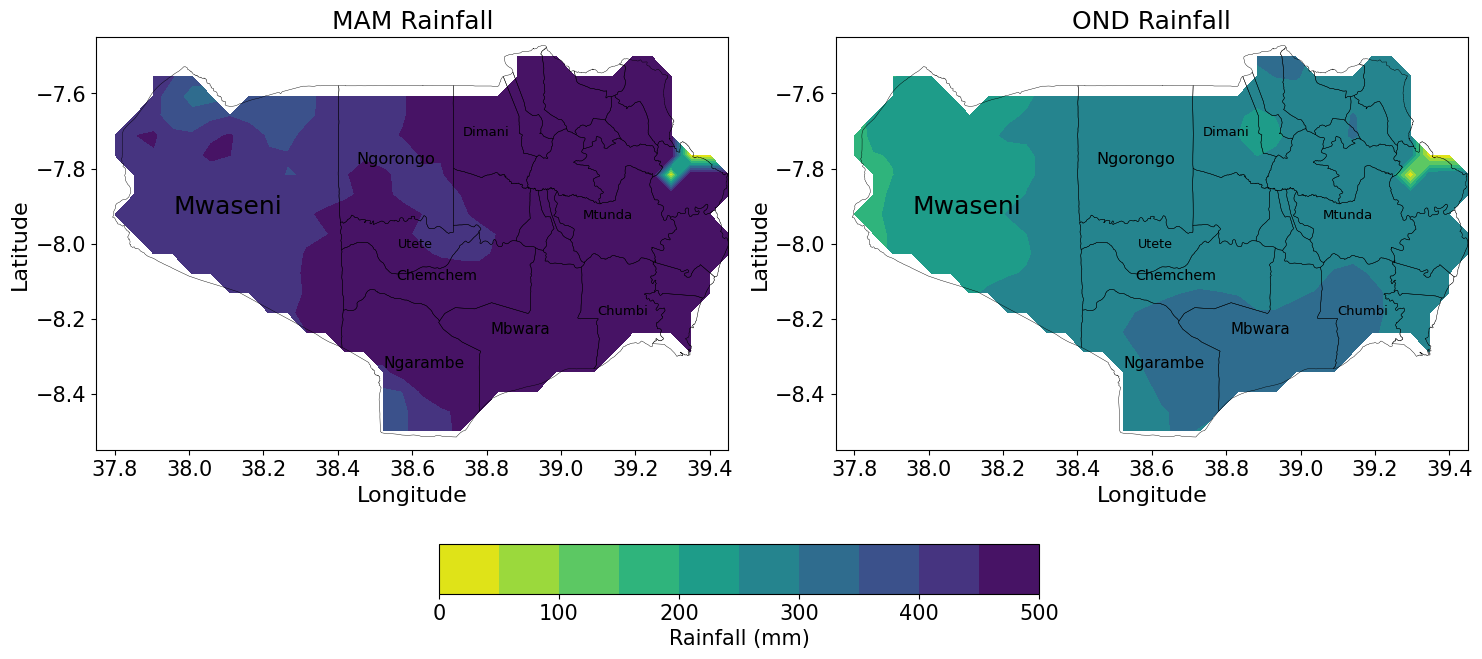

In [6]:
# Historical rainfall analysis
selected_admin = admin
rainfall_raster = 'data/prec/PRCP_monthlymean.tif'

# Create a list of geometries for those three regions:
three_geoms = [geom for geom in selected_admin.geometry]

# ─── Clip & Sum the months over aoi
# Rainy season for TZA: MAM and OND

mam_bands   = [3,4,5]  # Jan-Mar
ond_bands = [10, 11, 12]  # Oct-Dec


with rasterio.open(rainfall_raster) as src:
    
    # Mask to the aoi
    mam_clip, mam_transform = mask(
        src,
        shapes=three_geoms,       # <— use only the aoi here
        crop=True,
        indexes=mam_bands
    )

    ond_clip, ond_transform = mask(
        src,
        shapes=three_geoms,       # <— same here
        crop=True,
        indexes=ond_bands
    )
    
mam_sum   = np.sum(mam_clip, axis=0)
ond_sum = np.sum(ond_clip, axis=0)

# Build X/Y Grids for Contoured Plotting 
def make_xy_grid(arr2d, transform):
    nrows, ncols = arr2d.shape
    minx, miny, maxx, maxy = array_bounds(nrows, ncols, transform)
    xs = np.linspace(minx, maxx, ncols)
    ys = np.linspace(miny, maxy, nrows)[::-1]
    return np.meshgrid(xs, ys)

X_b, Y_b = make_xy_grid(mam_sum, mam_transform)
X_k, Y_k = make_xy_grid(ond_sum, ond_transform)

#  Plot: 1×3 Subplots 
fig_rain, axes_rain = plt.subplots(1, 2, figsize=(15, 10), subplot_kw={'aspect': 'equal'})
plt.rcParams.update({'font.size': 14, 'font.family': 'DejaVu Sans'})

rainfall_contour = None

plot_info_rain = [
    (0, mam_sum, X_b, Y_b, (0,500), np.linspace(0,500,11), 'viridis_r', 'MAM Rainfall'),
    (1, ond_sum, X_k, Y_k, (0,500), np.linspace(0,500,11), 'viridis_r', 'OND Rainfall'),
]

for ax_idx, data_arr, Xg, Yg, (vmin, vmax), levels, cmap, title in plot_info_rain:
    ax = axes_rain[ax_idx]
    data_vis = np.clip(data_arr, vmin, vmax)
    ctr = ax.contourf(Xg, Yg, data_vis, levels=levels, cmap=cmap)

    if rainfall_contour is None:
        rainfall_contour = ctr

    ax.set_title(title, fontsize=18)
    ax.set_xlabel('Longitude', fontsize=16)
    ax.set_ylabel('Latitude', fontsize=16)
    ax.tick_params(axis='both', labelsize=15)

    selected_admin.boundary.plot(ax=ax, edgecolor='black', linewidth=0.3)

    max_area = selected_admin.geometry.area.max()
    for _, row in selected_admin.iterrows():
     ratio = row.geometry.area / max_area
     if ratio < 0.1:  # skip the smallest
        continue
     fontsize = 8 + (ratio * 10)  # scale font between 8–18
     region_name = row['NAME_3']
     pt = row.geometry.representative_point()
     ax.text(pt.x, pt.y, region_name, fontsize=fontsize, ha='center', va='center', color='black')

    # for _, row in selected_admin.iterrows():
    #     region_name = row['NAME_3']
    #     pt = row.geometry.representative_point()
    #     ax.text(pt.x, pt.y, region_name, fontsize=13, ha='center', va='center', color='black')

cbar_ax_rain = fig_rain.add_axes([0.3, 0.05, 0.4, 0.05])
cbar_rain = fig_rain.colorbar(rainfall_contour, cax=cbar_ax_rain, orientation='horizontal', label='Rainfall (mm)')
cbar_rain.ax.tick_params(labelsize=15)
cbar_rain.ax.xaxis.label.set_size(15)

plt.tight_layout(rect=[0, 0.1, 1, 0.7])
plt.savefig('output/rufiji_ptot_climatology1.png', dpi=300, bbox_inches='tight', pad_inches=0.5)
plt.show()

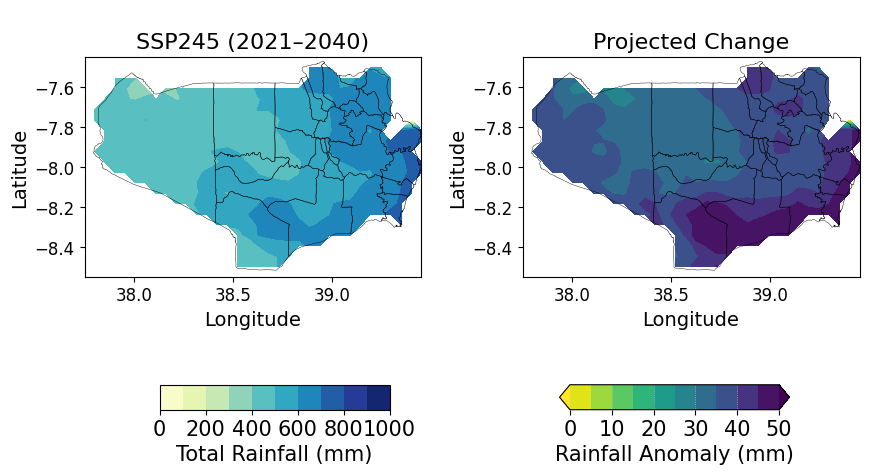

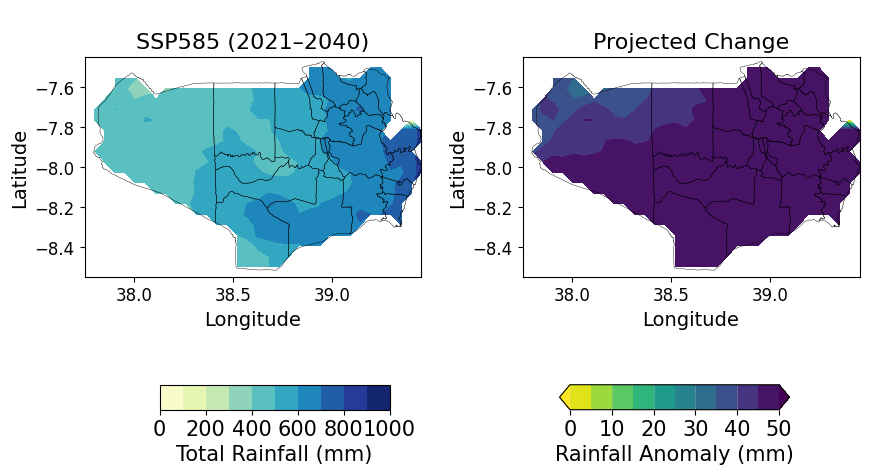

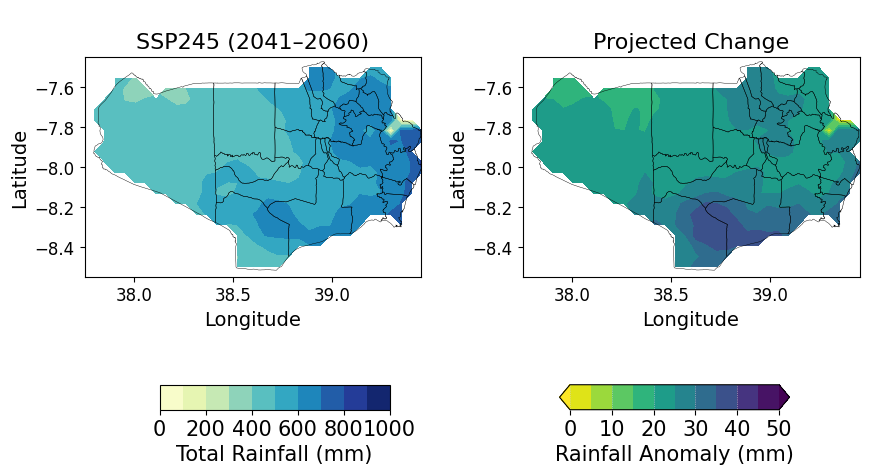

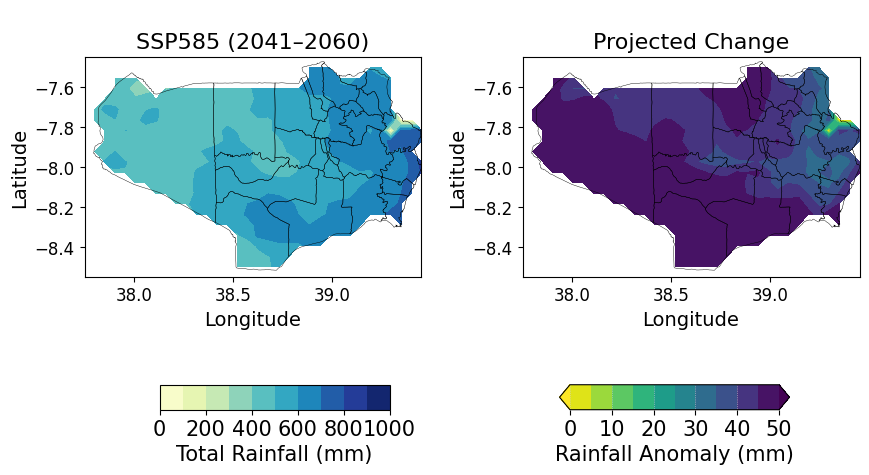

In [7]:
# Projected rainfall changes under ssp245 and ssp585
baseline_clim = 'data/prec/PRCP_monthlymean.tif'
future_files = {
    'SSP245 (2021–2040)': 'data/prec/ptot_ssp245_2021_2040.tif',
    'SSP585 (2021–2040)': 'data/prec/ptot_ssp585_2021_2040.tif',
    'SSP245 (2041–2060)': 'data/prec/ptot_ssp245_2041_2060.tif',
    'SSP585 (2041–2060)': 'data/prec/ptot_ssp585_2041_2060.tif'
}

# ─── 2) LOAD ADMIN LAYERS & REPROJECT ───────────────────────────────────────────────
# admin0 = gpd.read_file(admin0_path)
# admin1 = gpd.read_file(admin1_path)

# with rasterio.open(baseline_clim) as src:
#     raster_crs = src.crs

# if admin0.crs != raster_crs:
#     admin0 = admin0.to_crs(raster_crs)
# if admin1.crs != raster_crs:
#     admin1 = admin1.to_crs(raster_crs)

selected_admin = admin
selected_geom = [geom for geom in selected_admin.geometry]

# 3) DEFINE BAND INDICES 
mam_bands = [3,4,5]  # March-May

# 4) CLIP & SUM BASELINE OND
with rasterio.open(baseline_clim) as src:
    baseline_clip, baseline_transform = mask(
        src,
        shapes=selected_geom,
        crop=True,
        indexes=mam_bands
    )
baseline_mam = np.sum(baseline_clip, axis=0)

# 5) LOOP OVER FUTURE PROJECTIONS 
results = {}
for scenario_name, future_path in future_files.items():
    with rasterio.open(future_path) as src:
        fut_clip, fut_transform = mask(
            src,
            shapes=selected_geom,
            crop=True,
            indexes=mam_bands
        )
    future_mam = np.sum(fut_clip, axis=0)
    future_mam[future_mam < 0] = np.nan  # Avoid negatives

    anomaly = future_mam - baseline_mam

    results[scenario_name] = {
        'future_mam': future_mam,
        'future_transform': fut_transform,
        'anomaly': anomaly
    }

# 6) BUILD X/Y GRID FUNCTION 
def make_xy_grid(arr2d, transform):
    nrows, ncols = arr2d.shape
    minx, miny, maxx, maxy = array_bounds(nrows, ncols, transform)
    xs = np.linspace(minx, maxx, ncols)
    ys = np.linspace(miny, maxy, nrows)[::-1]
    return np.meshgrid(xs, ys)

X_base, Y_base = make_xy_grid(baseline_mam, baseline_transform)

# ─── 7) PLOTTING EACH SCENARIO ─────────────────────────────────────────────────────
for scenario_name, data_dict in results.items():
    fut_arr     = data_dict['future_mam']
    fut_tr      = data_dict['future_transform']
    anomaly_arr = data_dict['anomaly']

    X_fut, Y_fut = make_xy_grid(fut_arr, fut_tr)

    # fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'aspect': 'equal'})
    fig, axes = plt.subplots(1, 2, figsize=(10, 5), subplot_kw={'aspect': 'equal'})
    fig.subplots_adjust(wspace=0.3)  # minimize space between the two plots

    plt.rcParams.update({'font.size': 14, 'font.family': 'DejaVu Sans'})

    # Fixed limits 
    vmin_k, vmax_k = 0, 1000
    levels_k = np.linspace(vmin_k, vmax_k, 11)

    vmin_a, vmax_a = 0, 50
    levels_a = np.linspace(vmin_a, vmax_a, 11)

    # PANEL 1: Future MAM Mean 
    ax0 = axes[0]
    fut_vis = np.clip(fut_arr, vmin_k, vmax_k)
    c1 = ax0.contourf(X_fut, Y_fut, fut_vis, levels=levels_k, cmap='YlGnBu')
    ax0.set_title(f"{scenario_name}", fontsize=16)
    ax0.set_xlabel('Longitude', fontsize=14)
    ax0.set_ylabel('Latitude', fontsize=14)
    ax0.tick_params(labelsize=12)
    #admin0.boundary.plot(ax=ax0, edgecolor='black', linewidth=0.8)
    selected_admin.boundary.plot(ax=ax0, edgecolor='black', linewidth=0.3)

    for _, row in selected_admin.iterrows():
        pt = row.geometry.representative_point()
        # ax0.text(pt.x, pt.y, row['NAME_3'], fontsize=9, ha='center', va='center', color='black')

    #  PANEL 2: Anomaly 
    ax1 = axes[1]
    an_vis = np.clip(anomaly_arr, vmin_a, vmax_a)
    c2 = ax1.contourf(X_base, Y_base, an_vis, levels=levels_a, cmap='viridis_r', extend='both')
    ax1.set_title(f"\nProjected Change", fontsize=16)
    ax1.set_xlabel('Longitude', fontsize=14)
    ax1.set_ylabel('Latitude', fontsize=14)
    ax1.tick_params(labelsize=12)
    #admin0.boundary.plot(ax=ax1, edgecolor='black', linewidth=0.8)
    selected_admin.boundary.plot(ax=ax1, edgecolor='black', linewidth=0.3)
    for _, row in selected_admin.iterrows():
        pt = row.geometry.representative_point()
        # ax1.text(pt.x, pt.y, row['NAME_3'], fontsize=9, ha='center', va='center', color='black')

    # ─── 8) ADD COLORBARS ───────────────────────────────────────────────────────────
    cax0 = fig.add_axes([0.2, 0.01, 0.23, 0.05])
    cb0 = fig.colorbar(c1, cax=cax0, orientation='horizontal', label='Total Rainfall (mm)')
    cb0.ax.tick_params(labelsize=15)
    cb0.ax.xaxis.label.set_size(15)

    cax1 = fig.add_axes([0.6, 0.01, 0.23, 0.05])
    cb1 = fig.colorbar(c2, cax=cax1, orientation='horizontal', label='Rainfall Anomaly (mm)')
    cb1.ax.tick_params(labelsize=15)
    cb1.ax.xaxis.label.set_size(15)

    plt.grid(True, linestyle=':', linewidth=0.5, color='lightgray')
    #plt.tight_layout(rect=[0.1, 0.10, 1, 0.95])

    # ─── 9) SAVE FIGURE ─────────────────────────────────────────────────────────────
    outname = f"output/MAM_{scenario_name.replace(' ', '_')}_mean_anomaly.png"
    plt.savefig(outname, dpi=300, bbox_inches='tight')
    plt.show()

In [10]:
# Rainfall stats
# rainfall_raster = 'data/historical/PRCP_monthlymean.tif'

#  Match CRS with raster 
with rasterio.open(rainfall_raster) as rf:
    raster_crs = rf.crs

if selected_admin.crs != raster_crs:
    selected_admin = selected_admin.to_crs(raster_crs)

# ─── Define month bands ──────────────────────────────────────────────────────────
# jfm_bands   = [1, 2, 3]  # Jan - Apr
mam_bands = [3,4,5] # Apr-Jun
# jas_bands = [7, 8, 9]
ond_bands = [10, 11, 12]  # Oct – Nov

# ─── Initialize results ──────────────────────────────────────────────────────────
results = []

with rasterio.open(rainfall_raster) as rf_src: #rasterio.open(temp_raster) as t_src:
    for idx, row in selected_admin.iterrows():
        region_name = row['NAME_3']
        geom        = [row.geometry]

        # ── Monthly average rainfall ─────────────────────────────────────────────
        monthly_avg_mam = []
        # monthly_avg_amj = []
        # monthly_avg_jas = []
        monthly_avg_ond = []

        for band in mam_bands:
            month_clip, _ = mask(rf_src, shapes=geom, crop=False, indexes=[band])
            month_data = month_clip[0]
            valid = month_data[~np.isnan(month_data)]
            monthly_avg_mam.append(np.mean(valid) if valid.size > 0 else np.nan)

        # for band in amj_bands:
        #     month_clip, _ = mask(rf_src, shapes=geom, crop=False, indexes=[band])
        #     month_data = month_clip[0]
        #     valid = month_data[~np.isnan(month_data)]
        #     monthly_avg_amj.append(np.mean(valid) if valid.size > 0 else np.nan)

        # for band in jas_bands:
        #     month_clip, _ = mask(rf_src, shapes=geom, crop=False, indexes=[band])
        #     month_data = month_clip[0]
        #     valid = month_data[~np.isnan(month_data)]
        #     monthly_avg_jas.append(np.mean(valid) if valid.size > 0 else np.nan)

        for band in ond_bands:
            month_clip, _ = mask(rf_src, shapes=geom, crop=False, indexes=[band])
            month_data = month_clip[0]
            valid = month_data[~np.isnan(month_data)]
            monthly_avg_ond.append(np.mean(valid) if valid.size > 0 else np.nan)

        mam_avg_total   = np.nansum(monthly_avg_mam)
        # amj_avg_total   = np.nansum(monthly_avg_amj)
        # jas_avg_total   = np.nansum(monthly_avg_jas)
        ond_avg_total = np.nansum(monthly_avg_ond)
        total_rain_avg   = mam_avg_total + ond_avg_total

        # Save results 
        results.append({
            'region': region_name,
            'mam_mean_sum_mm':   mam_avg_total,
            # 'amj_mean_sum_mm':   amj_avg_total,
            # 'jas_mean_sum_mm':   jas_avg_total,
            'ond_mean_sum_mm': ond_avg_total,
            'total_rain_avg_mm':  total_rain_avg
        })

# Output DataFrame 
df = pd.DataFrame(results)
print(df.to_string(index=False))
df.to_csv("output/historical_rain_season_rufiji.csv")

    region  mam_mean_sum_mm  ond_mean_sum_mm  total_rain_avg_mm
     Bungu       578.947693       293.837769         872.785461
  Chemchem       493.293457       284.121033         777.414490
    Chumbi       587.177246       306.915833         894.093079
    Dimani       509.484406       262.712708         772.197144
  Ikwiriri       527.029907       276.609711         803.639648
    Kibiti       558.214417       263.236267         821.450684
Kiongoroni       687.765564       272.122620         959.888184
    Mahege       606.432495       292.041260         898.473755
  Maparoni       681.339355       281.946350         963.285706
    Mbuchi       654.817932       274.744873         929.562805
    Mbwara       560.743042       311.396118         872.139160
   Mchukwi       579.032837       283.097870         862.130737
    Mgomba       531.342224       277.538208         808.880432
     Mjawa       556.212524       287.717346         843.929871
    Mkongo       481.918945       272.14